In [3]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [5]:
!pip install ucimlrepo

In [6]:
from ucimlrepo import fetch_ucirepo

In [7]:
phishing = fetch_ucirepo(id=967)

X = phishing.data.features
y = phishing.data.targets

print(X.shape)
print(y.shape)

(235795, 54)
(235795, 1)


In [8]:
X.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,1,0,0,1,34,20,28,119,0,124
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,0,1,50,9,8,39,0,217
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,0,1,10,2,7,42,2,5
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,0,1,1,1,3,27,15,22,1,31
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,1,0,1,244,15,34,72,1,85


In [9]:
y.head()

,label
0,1
1,1
2,1
3,1
4,1


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 54 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [11]:
X.isnull().sum()

,0
URL,0
URLLength,0
Domain,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0
URLCharProb,0


In [12]:
y.value_counts()

,count
label,
1,134850
0,100945


In [13]:
y.iloc[:,0].value_counts()

,count
label,
1,134850
0,100945


In [14]:
print(y.columns)

Index(['label'], dtype='object')


In [15]:
print(X.columns.tolist())

['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(188636, 54)
(47159, 54)
(188636, 1)
(47159, 1)


In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
lr_model = LogisticRegression(max_iter=1000)

In [20]:
X = X.drop(columns=["URL", "Domain", "TLD", "Title"])

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URLLength                   235795 non-null  int64  
 1   DomainLength                235795 non-null  int64  
 2   IsDomainIP                  235795 non-null  int64  
 3   URLSimilarityIndex          235795 non-null  float64
 4   CharContinuationRate        235795 non-null  float64
 5   TLDLegitimateProb           235795 non-null  float64
 6   URLCharProb                 235795 non-null  float64
 7   TLDLength                   235795 non-null  int64  
 8   NoOfSubDomain               235795 non-null  int64  
 9   HasObfuscation              235795 non-null  int64  
 10  NoOfObfuscatedChar          235795 non-null  int64  
 11  ObfuscationRatio            235795 non-null  float64
 12  NoOfLettersInURL            235795 non-null  int64  
 13  LetterRatioInU

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
print(y.head())

   label
0      1
1      1
2      1
3      1
4      1


In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [25]:
lr_model.fit(X_train, y_train.values.ravel())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train.values.ravel())

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.9998727708390763
Precision: 0.9997775800711743
Recall   : 1.0
F1 Score : 0.9998887776665555
ROC AUC  : 0.9999999779613244


In [32]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[20183     6]
 [    0 26970]]


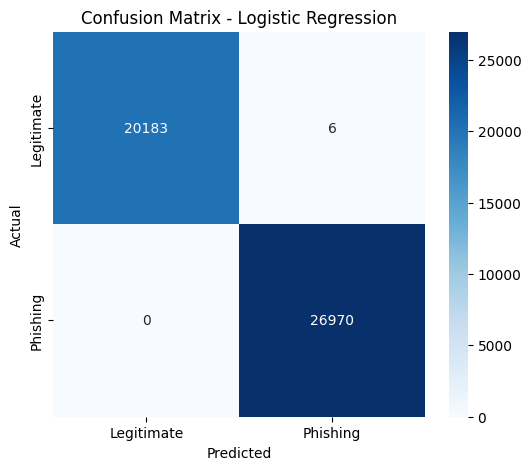

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [34]:
print(X.columns.tolist())

['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

In [36]:
svm_model.fit(X_train_scaled, y_train.values.ravel())

LinearSVC(max_iter=5000, random_state=42)

In [37]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [38]:
y_score_svm = svm_model.decision_function(X_test_scaled)

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_score_svm))

Accuracy : 0.9999151805593842
Precision: 0.9998517090531623
Recall   : 1.0
F1 Score : 0.9999258490286222
ROC AUC  : 0.9999999908172185


In [40]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[20185     4]
 [    0 26970]]


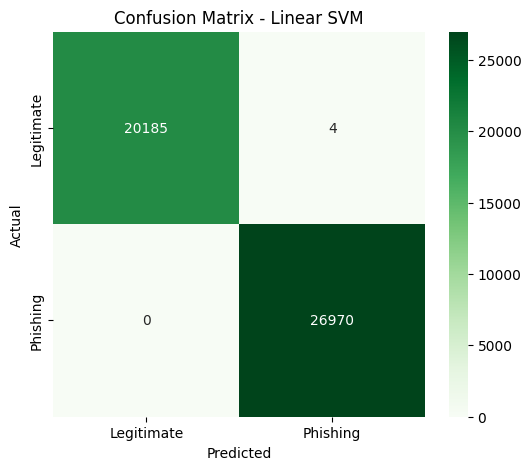

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [44]:
rf_model.fit(X_train, y_train.values.ravel())

RandomForestClassifier(n_jobs=-1, random_state=42)

In [45]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


In [47]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[20189     0]
 [    0 26970]]


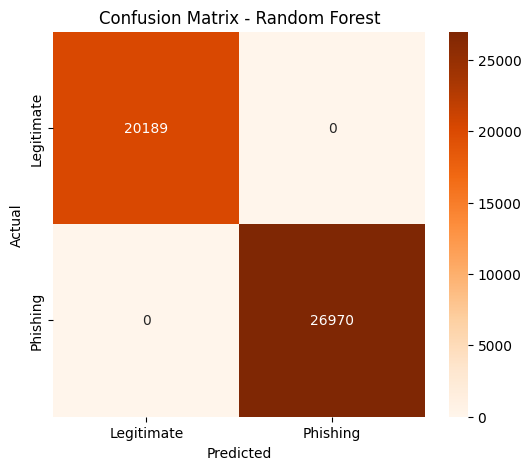

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [49]:
import pandas as pd

# Combine features and label
df = X.copy()
df["label"] = y.values

# Check correlation with the label
corr = df.corr(numeric_only=True)["label"].sort_values(ascending=False)

print(corr.head(15))

label                    1.000000
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
Name: label, dtype: float64


In [50]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                       Feature  Importance
3           URLSimilarityIndex    0.181075
49             NoOfExternalRef    0.169265
22                  LineOfCode    0.146585
47                 NoOfSelfRef    0.108536
44                   NoOfImage    0.084350
46                      NoOfJS    0.072904
45                     NoOfCSS    0.031598
36                HasSocialNet    0.031526
43            HasCopyrightInfo    0.025522
21                     IsHTTPS    0.022940
23           LargestLineLength    0.018937
19  NoOfOtherSpecialCharsInURL    0.018225
32              HasDescription    0.018072
14             NoOfDegitsInURL    0.012960
15             DegitRatioInURL    0.008390
12            NoOfLettersInURL    0.008281
29                IsResponsive    0.006173
25       DomainTitleMatchScore    0.006025
0                    URLLength    0.005451
13            LetterRatioInURL    0.004243


In [65]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        0.9998727708390763,
        0.9999151805593842,
        1.0000000000000000
    ],
    "Precision": [
        0.9997775800711743,
        0.9998517090531623,
        1.0000000000000000
    ],
    "Recall": [
        1.0,
        1.0,
        1.0
    ],
    "F1 Score": [
        0.9998887776665555,
        0.9999258490286222,
        1.0
    ],
    "ROC-AUC": [
        0.9999999779613244,
        0.9999999908172185,
        1.0
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression  0.999873   0.999778     1.0  0.999889      1.0
1           Linear SVM  0.999915   0.999852     1.0  0.999926      1.0
2        Random Forest  1.000000   1.000000     1.0  1.000000      1.0


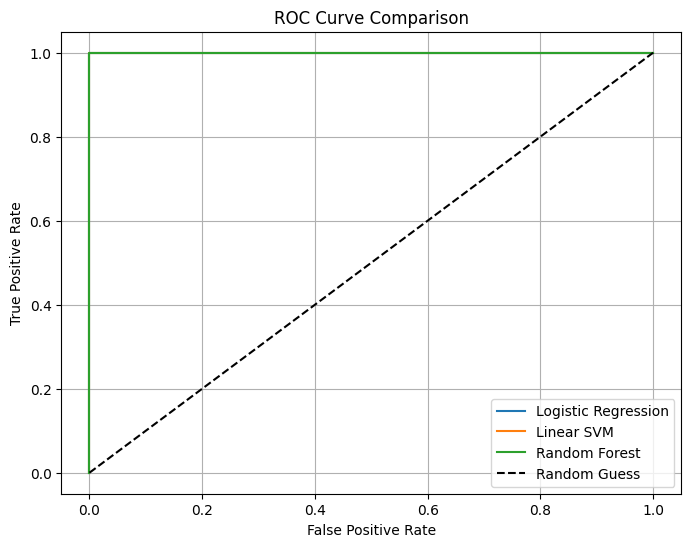

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Linear SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_svm, tpr_svm, label='Linear SVM')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.grid(True)

plt.show()

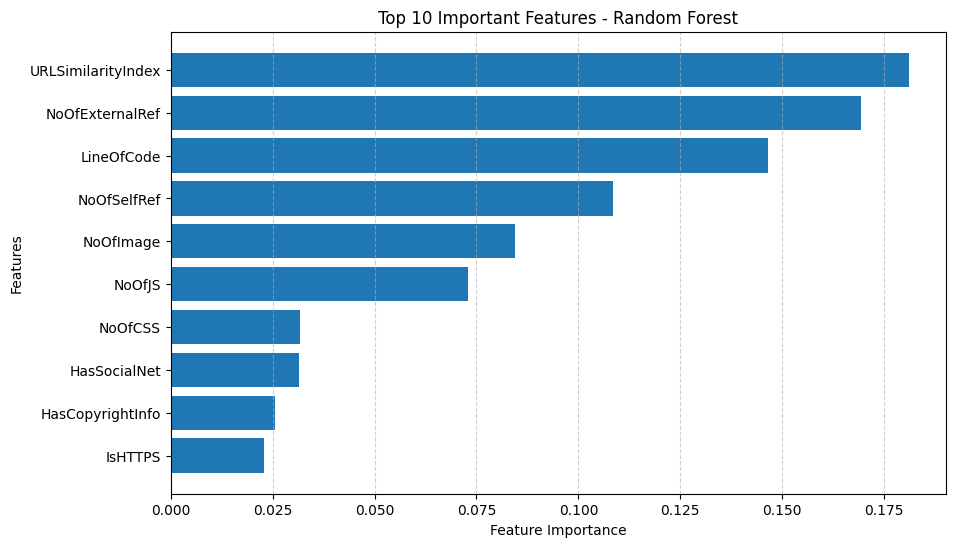

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame of feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Select top 10 features
top10 = importance.head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(top10['Feature'], top10['Importance'])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

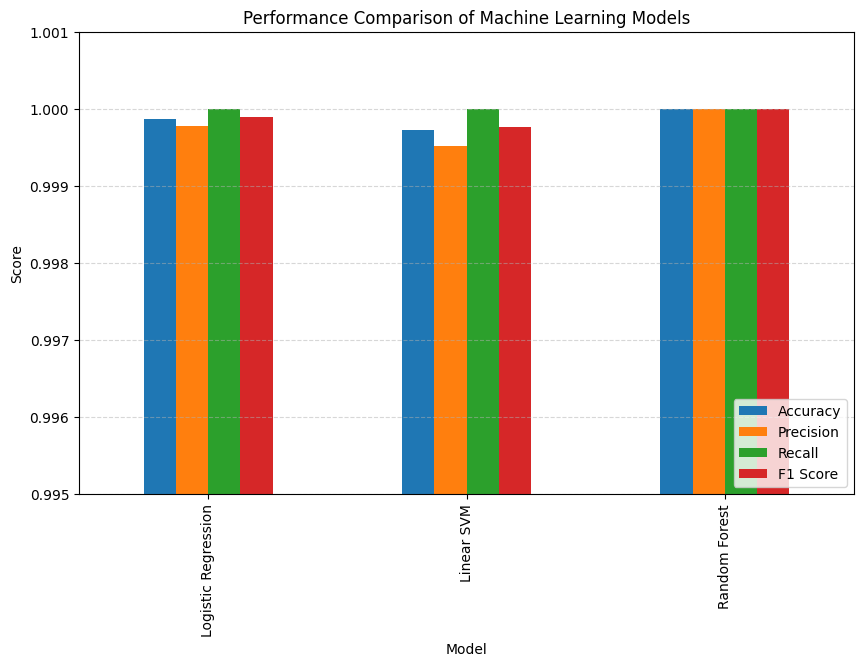

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest'],
    'Accuracy': [0.9998727708390763, 0.9997243368179987, 1.0],
    'Precision': [0.9997775800711743, 0.999518215172516, 1.0],
    'Recall': [1.0, 1.0, 1.0],
    'F1 Score': [0.9998887776665555, 0.9997590495431209, 1.0]
})

results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0.995, 1.001)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

plt.show()

# Feature Ablation Study

In [55]:
# Remove the most important feature
X_ablation = X.drop(columns=['URLSimilarityIndex'])

print(X_ablation.shape)

(235795, 49)


In [56]:
from sklearn.model_selection import train_test_split

X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X_ablation,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_ab_scaled = scaler.fit_transform(X_train_ab)
X_test_ab_scaled = scaler.transform(X_test_ab)

In [58]:
from sklearn.linear_model import LogisticRegression

lr_ab = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_ab.fit(
    X_train_ab_scaled,
    y_train_ab.values.ravel()
)

LogisticRegression(max_iter=1000, random_state=42)

In [59]:
y_pred_lr_ab = lr_ab.predict(X_test_ab_scaled)

In [60]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test_ab, y_pred_lr_ab))

LR Accuracy: 0.9991518055938421


In [61]:
from sklearn.svm import LinearSVC

svm_ab = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm_ab.fit(
    X_train_ab_scaled,
    y_train_ab.values.ravel()
)

LinearSVC(max_iter=5000, random_state=42)

In [62]:
y_pred_svm_ab = svm_ab.predict(X_test_ab_scaled)

print(
    "SVM Accuracy:",
    accuracy_score(y_test_ab, y_pred_svm_ab)
)

SVM Accuracy: 0.9998303611187684


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_ab = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_ab.fit(
    X_train_ab,
    y_train_ab.values.ravel()
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [64]:
y_pred_rf_ab = rf_ab.predict(X_test_ab)

print(
    "RF Accuracy:",
    accuracy_score(y_test_ab, y_pred_rf_ab)
)

RF Accuracy: 0.9998939756992302
